## Dataset Overview

#### Import Libraries & Load Dataset

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
df = pd.read_csv("Data/final_clean_data.csv")
print(f"Shape of dataset: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Shape of dataset: 45251 rows × 22 columns


,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,ORIGIN,ORIGIN_STATE_ABR,DEST,DEST_STATE_ABR,CRS_DEP_TIME,DEP_DELAY,...,DEP_DELAY_GROUP,CRS_ARR_TIME,CRS_ELAPSED_TIME,DISTANCE,DISTANCE_GROUP,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyRelativeHumidity,HourlyVisibility,HourlyWindSpeed
0,4,1,2,AA,GEG,WA,PHX,AZ,6.53,-5.0,...,-1.0,9.33,168.0,1020.0,5,33.0,36.0,89.0,5.0,10.0
1,4,1,2,AA,GEG,WA,PHX,AZ,15.45,15.0,...,1.0,18.12,160.0,1020.0,5,33.0,45.0,63.0,10.0,10.0
2,4,1,2,AA,SEA,WA,CLT,NC,7.33,-3.0,...,-1.0,15.32,299.0,2279.0,10,37.0,43.0,80.0,10.0,6.0
3,4,1,2,AA,SEA,WA,CLT,NC,13.83,-3.0,...,-1.0,21.83,300.0,2279.0,10,41.0,49.0,74.0,10.0,6.0
4,4,1,2,AA,SEA,WA,CLT,NC,22.00,-6.0,...,-1.0,6.00,300.0,2279.0,10,41.0,45.0,86.0,10.0,7.0


#### Basic information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45251 entries, 0 to 45250
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   MONTH                      45251 non-null  int64  
 1   DAY_OF_MONTH               45251 non-null  int64  
 2   DAY_OF_WEEK                45251 non-null  int64  
 3   OP_UNIQUE_CARRIER          45251 non-null  object 
 4   ORIGIN                     45251 non-null  object 
 5   ORIGIN_STATE_ABR           45251 non-null  object 
 6   DEST                       45251 non-null  object 
 7   DEST_STATE_ABR             45251 non-null  object 
 8   CRS_DEP_TIME               45251 non-null  float64
 9   DEP_DELAY                  45251 non-null  float64
 10  DEP_DELAY_NEW              45251 non-null  float64
 11  DEP_DEL15                  45251 non-null  float64
 12  DEP_DELAY_GROUP            45251 non-null  float64
 13  CRS_ARR_TIME               45251 non-null  flo

In [6]:
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
MONTH                        0
DAY_OF_MONTH                 0
DAY_OF_WEEK                  0
OP_UNIQUE_CARRIER            0
ORIGIN                       0
ORIGIN_STATE_ABR             0
DEST                         0
DEST_STATE_ABR               0
CRS_DEP_TIME                 0
DEP_DELAY                    0
DEP_DELAY_NEW                0
DEP_DEL15                    0
DEP_DELAY_GROUP              0
CRS_ARR_TIME                 0
CRS_ELAPSED_TIME             0
DISTANCE                     0
DISTANCE_GROUP               0
HourlyDewPointTemperature    0
HourlyDryBulbTemperature     0
HourlyRelativeHumidity       0
HourlyVisibility             0
HourlyWindSpeed              0
dtype: int64


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MONTH,45251.0,5.081081,0.812057,4.00,4.00,5.0,6.00,6.00
DAY_OF_MONTH,45251.0,15.932311,8.731382,1.00,8.00,16.0,23.00,31.00
DAY_OF_WEEK,45251.0,3.984199,2.005295,1.00,2.00,4.0,6.00,7.00
CRS_DEP_TIME,45251.0,13.870102,5.251356,0.08,9.67,13.5,17.98,23.98
DEP_DELAY,45251.0,8.482266,25.674150,-9.00,-5.00,-1.0,11.00,200.00
DEP_DELAY_NEW,45251.0,11.194824,24.268551,0.00,0.00,0.0,11.00,200.00
DEP_DEL15,45251.0,0.218979,0.413559,0.00,0.00,0.0,0.00,1.00
DEP_DELAY_GROUP,45251.0,0.032618,1.763622,-1.00,-1.00,-1.0,0.00,12.00
CRS_ARR_TIME,45251.0,15.308281,5.624470,0.02,11.50,16.0,19.50,23.98
CRS_ELAPSED_TIME,45251.0,186.627765,85.743290,49.00,128.00,167.0,247.00,411.00


In [8]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical features ({len(cat_cols)}): {cat_cols}")

for col in cat_cols:
    unique_vals = df[col].nunique()
    print(f"{col}: {unique_vals} unique values")

Categorical features (5): ['OP_UNIQUE_CARRIER', 'ORIGIN', 'ORIGIN_STATE_ABR', 'DEST', 'DEST_STATE_ABR']
OP_UNIQUE_CARRIER: 12 unique values
ORIGIN: 5 unique values
ORIGIN_STATE_ABR: 1 unique values
DEST: 86 unique values
DEST_STATE_ABR: 36 unique values


In [9]:
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


## Target and Feature Distributions

### Target Distributions

In [10]:
# Target Variable Overview (DEP_DEL15)

target_counts = df["DEP_DEL15"].value_counts()
target_percent = df["DEP_DEL15"].value_counts(normalize=True) * 100

print("Counts of target variable:")
print(target_counts)
print("\nPercentage distribution:")
print(target_percent.round(2))

Counts of target variable:
DEP_DEL15
0.0    35342
1.0     9909
Name: count, dtype: int64

Percentage distribution:
DEP_DEL15
0.0    78.1
1.0    21.9
Name: proportion, dtype: float64


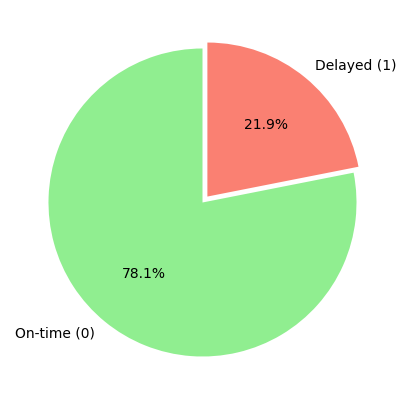

In [57]:
# Pie Chart

plt.figure(figsize=(5,5))
plt.pie(target_counts,
        labels=['On-time (0)','Delayed (1)'],
        autopct='%1.1f%%',
        startangle=90,
        colors=["lightgreen","salmon"],
        explode=(0, 0.05))
# plt.title("Flight Delay Distribution (DEP_DEL15)")
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_18268\3724002815.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="DEP_DEL15", data=df, palette=["lightgreen","salmon"])


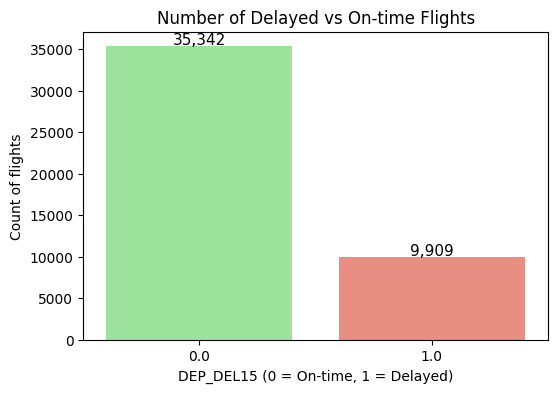

In [12]:
# Bar Chart

plt.figure(figsize=(6,4))
sns.countplot(x="DEP_DEL15", data=df, palette=["lightgreen","salmon"])
plt.title("Number of Delayed vs On-time Flights")
plt.xlabel("DEP_DEL15 (0 = On-time, 1 = Delayed)")
plt.ylabel("Count of flights")
for i, count in enumerate(target_counts):
    plt.text(i, count + 200, f"{count:,}", ha='center', fontsize=11)
plt.show()

### Feature Distributions

In [13]:
# Identify Numeric and Categorical Features

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
if "DEP_DEL15" in numeric_cols:
    numeric_cols.remove("DEP_DEL15")
categorical_cols = df.select_dtypes(include="object").columns.tolist()
print("Numeric features:", numeric_cols)
print("Categorical features:", categorical_cols)

Numeric features: ['MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'CRS_DEP_TIME', 'DEP_DELAY', 'DEP_DELAY_NEW', 'DEP_DELAY_GROUP', 'CRS_ARR_TIME', 'CRS_ELAPSED_TIME', 'DISTANCE', 'DISTANCE_GROUP', 'HourlyDewPointTemperature', 'HourlyDryBulbTemperature', 'HourlyRelativeHumidity', 'HourlyVisibility', 'HourlyWindSpeed']
Categorical features: ['OP_UNIQUE_CARRIER', 'ORIGIN', 'ORIGIN_STATE_ABR', 'DEST', 'DEST_STATE_ABR']


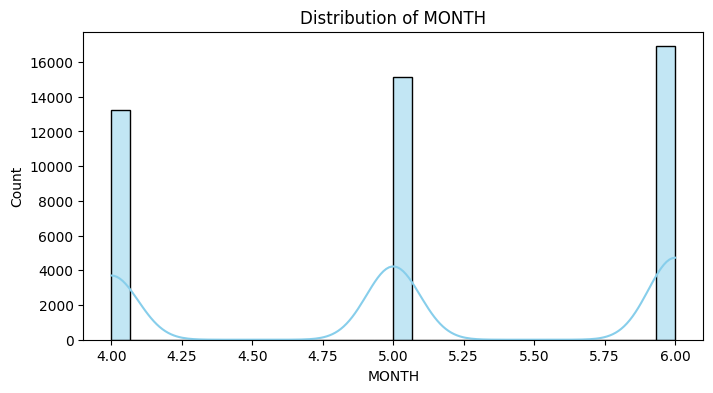

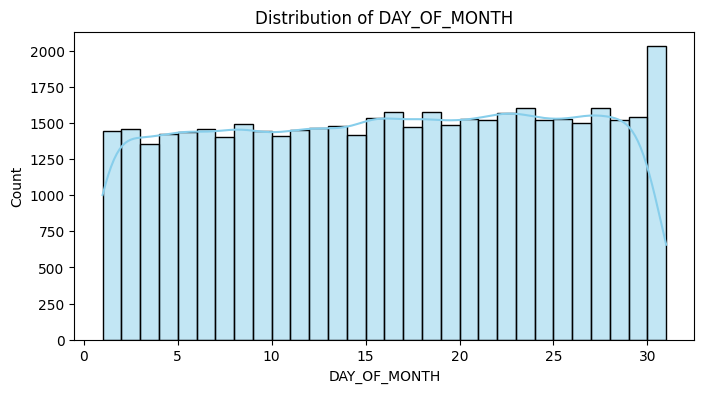

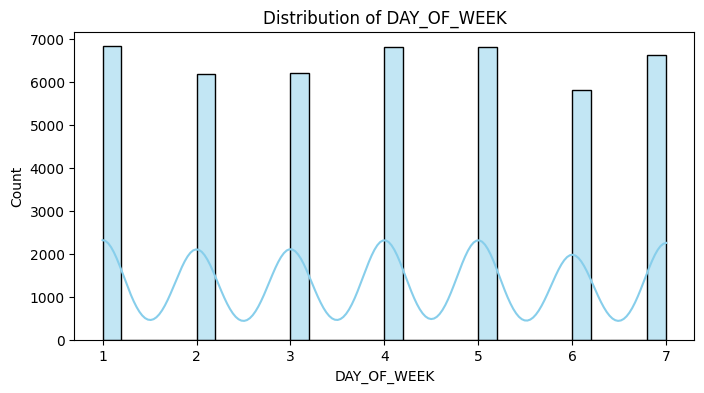

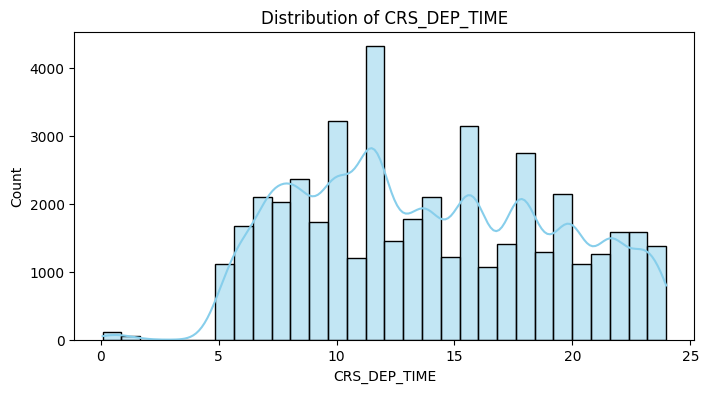

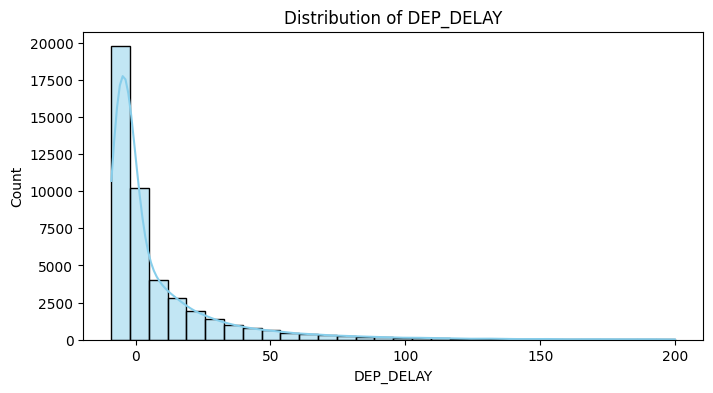

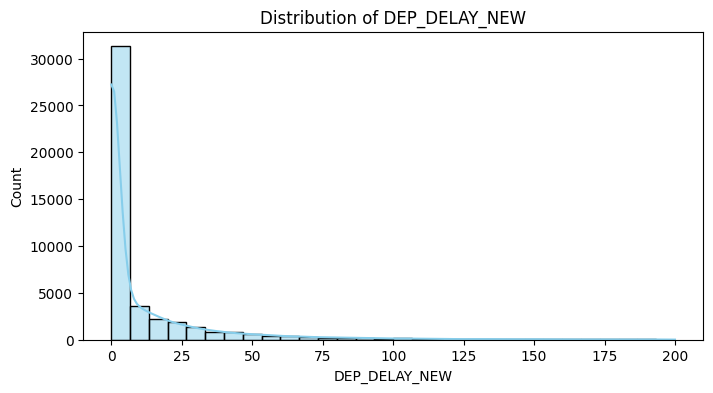

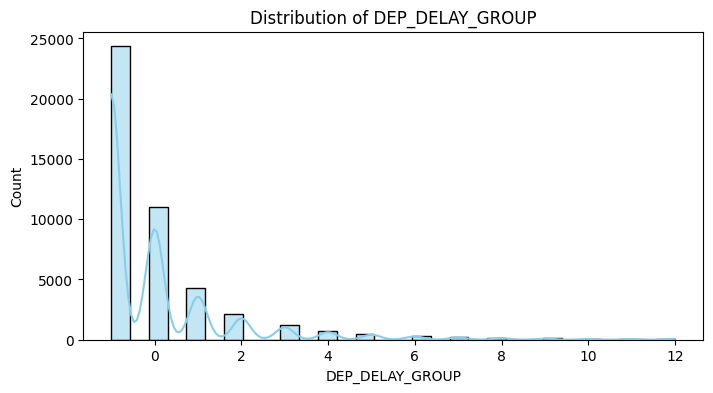

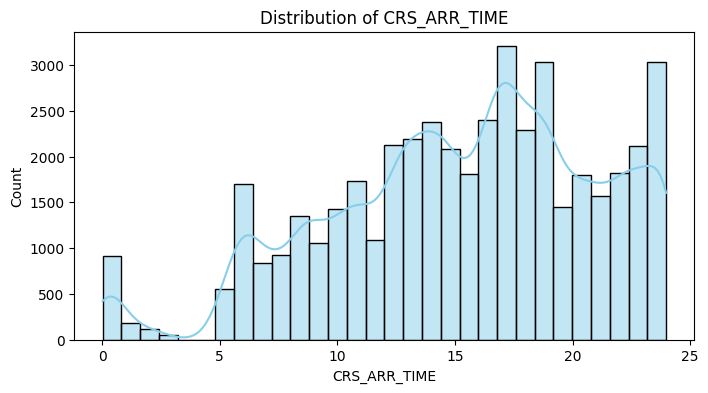

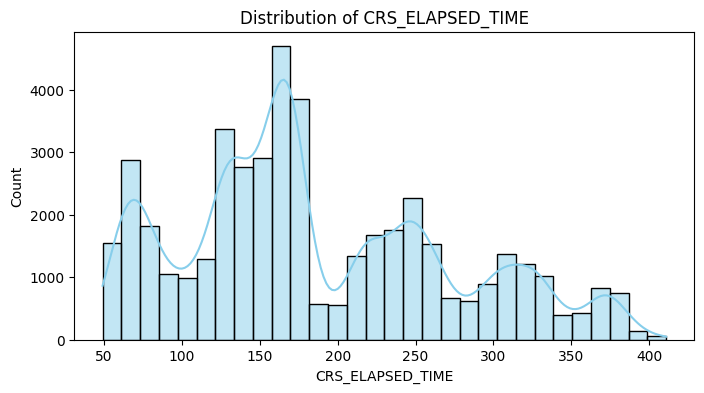

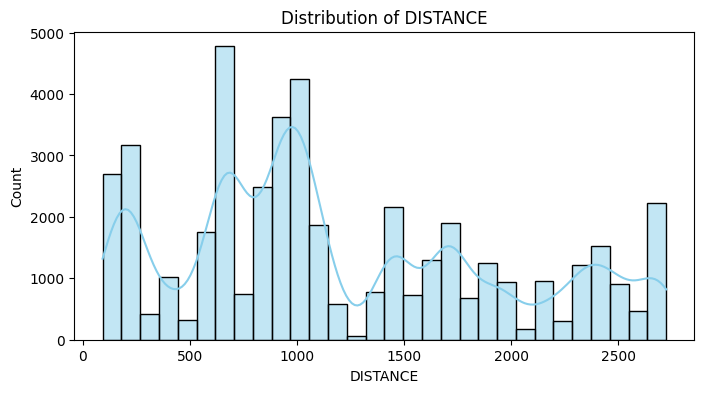

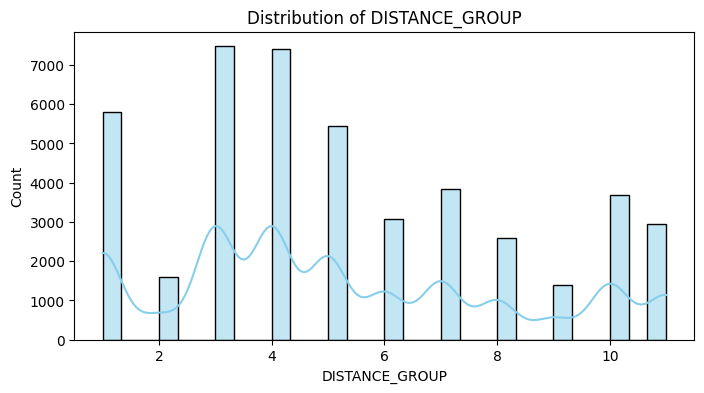

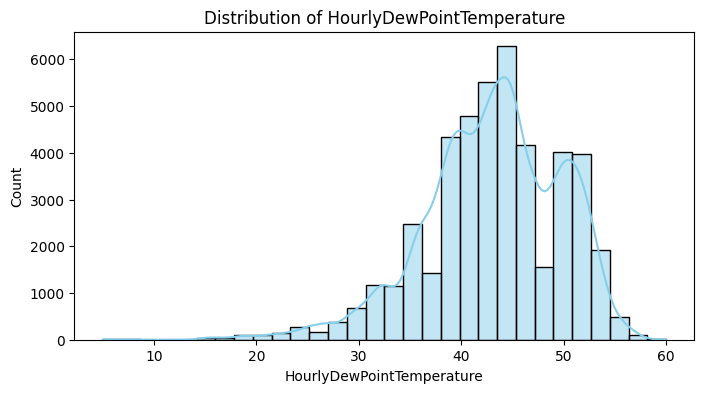

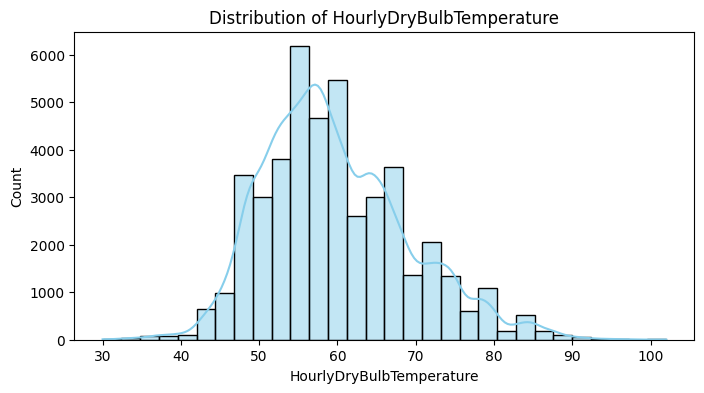

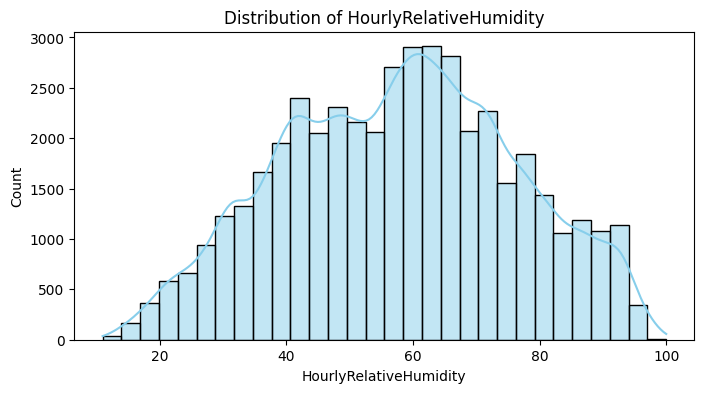

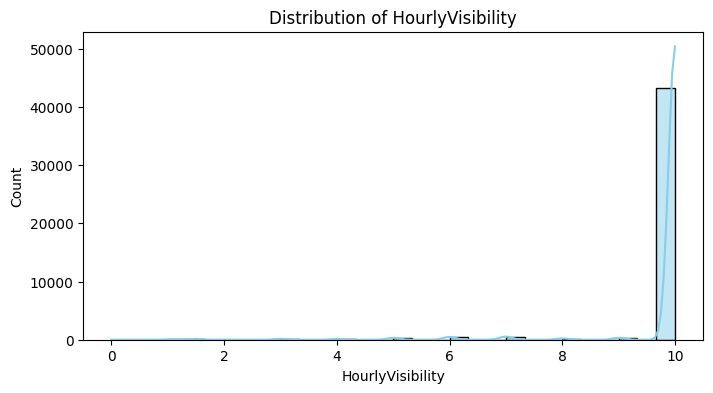

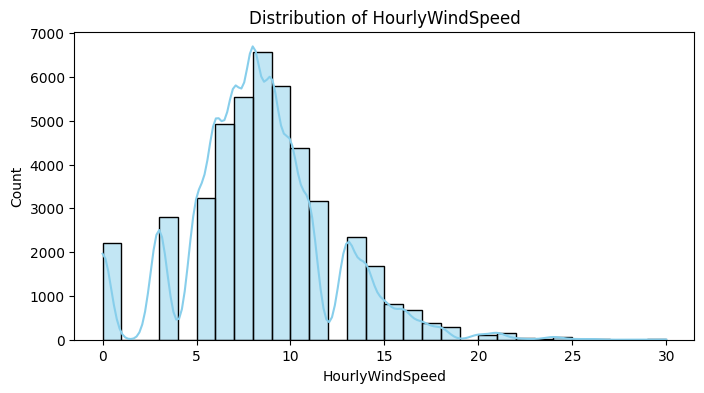

In [14]:
# Distribution of Numeric Features

for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

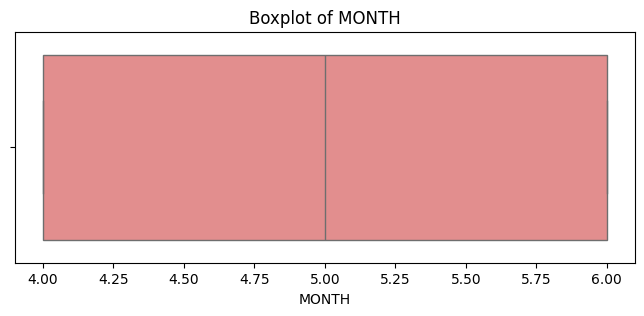

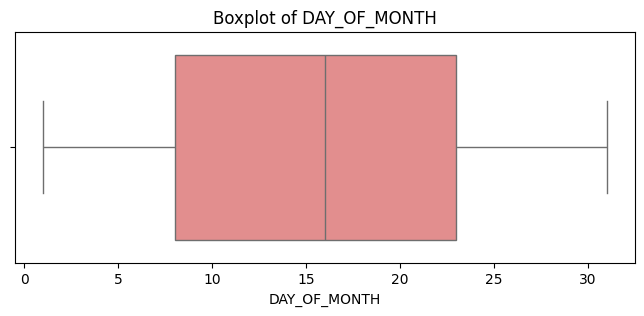

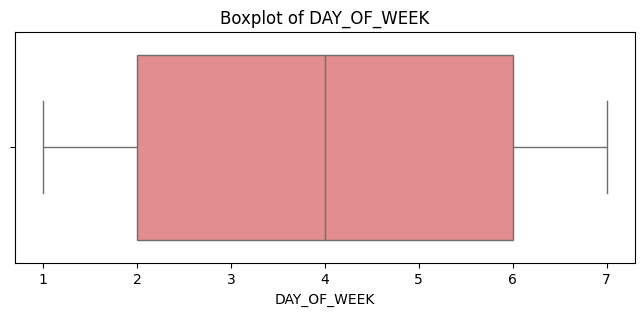

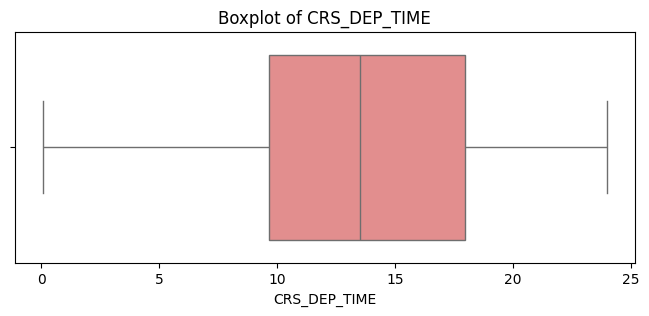

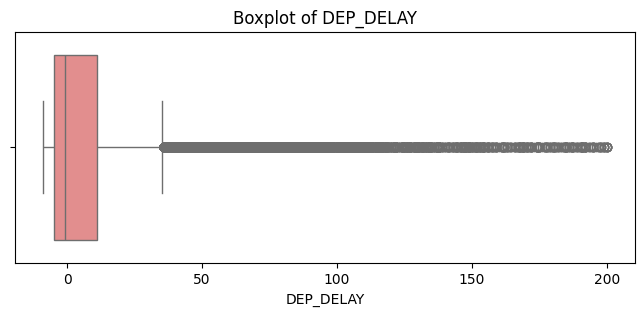

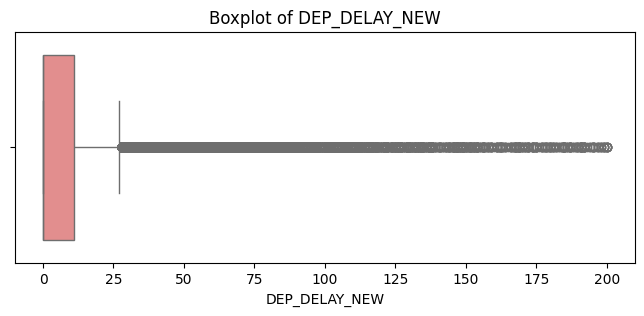

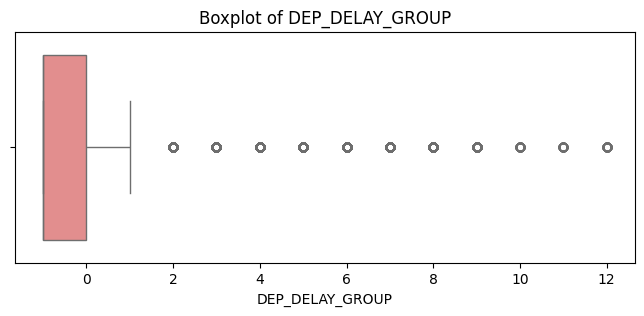

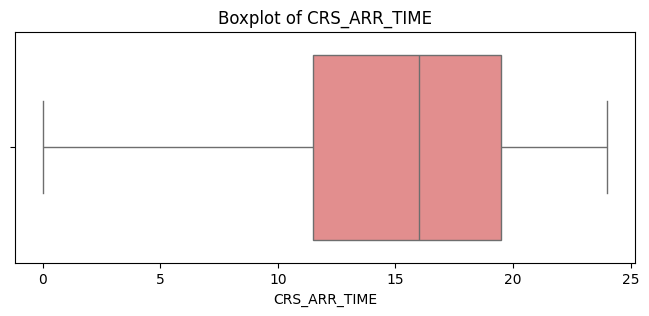

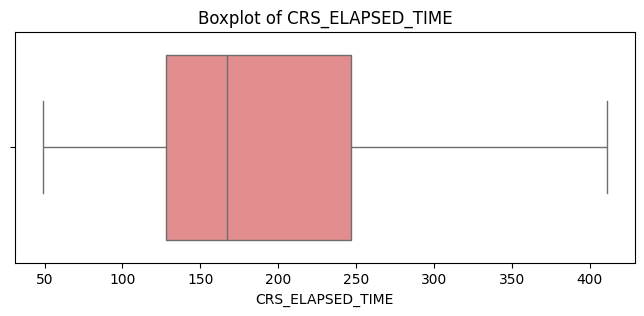

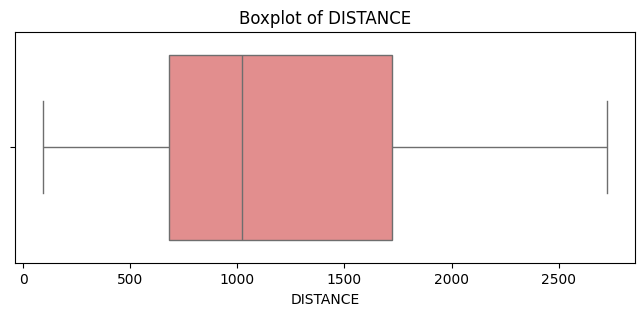

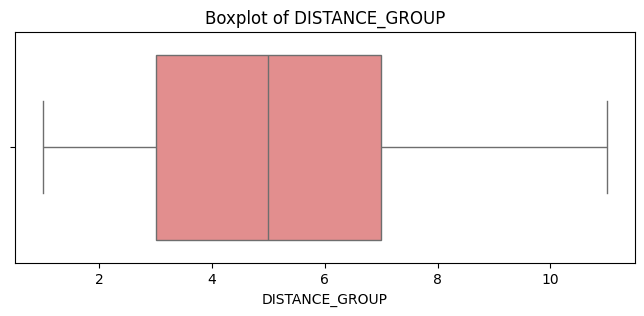

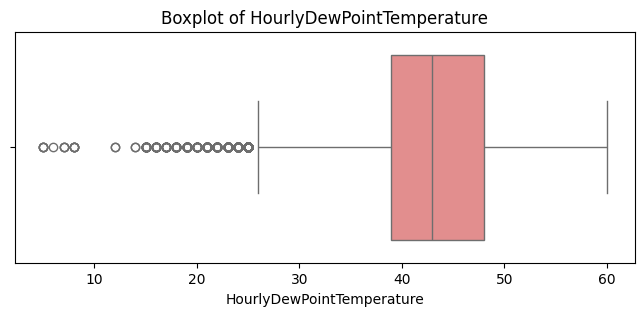

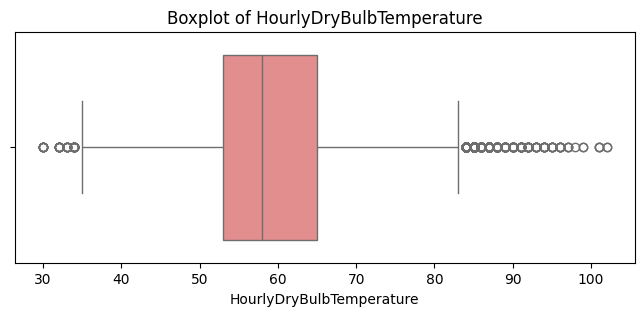

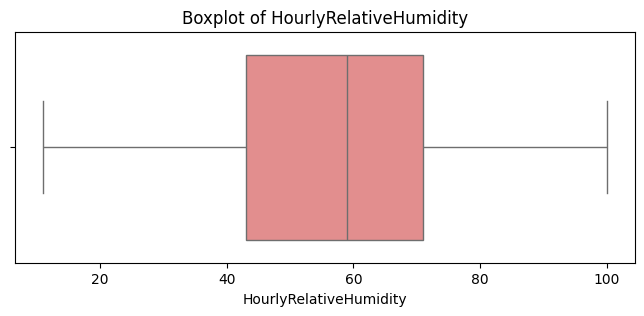

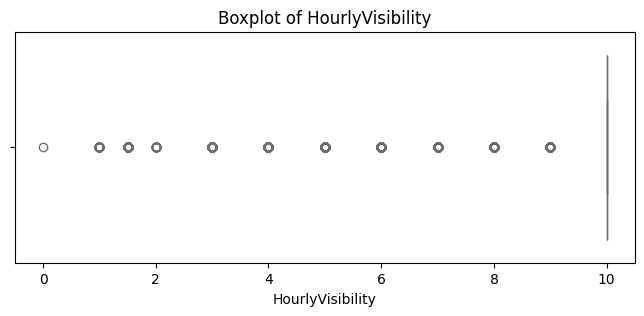

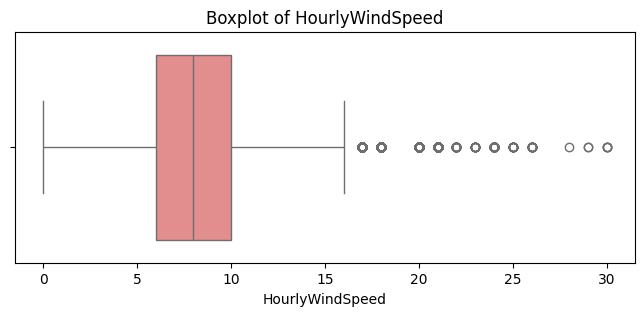

In [15]:
# Boxplots for Numeric Features

for col in numeric_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_18268\254782690.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="crest",


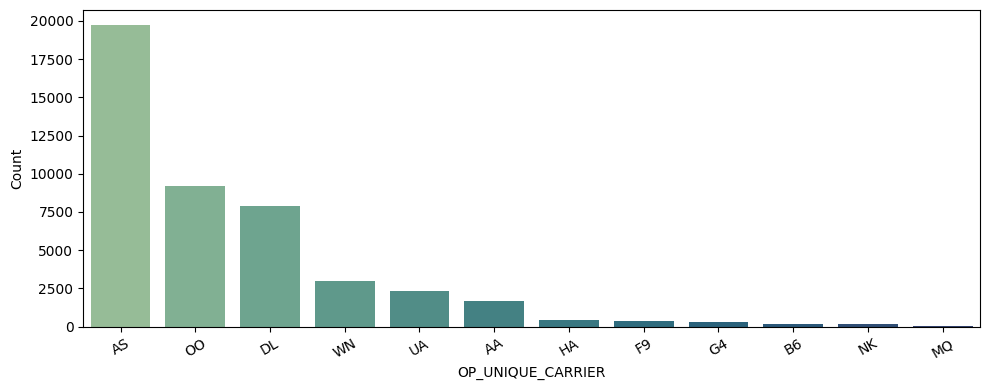

C:\Users\PC\AppData\Local\Temp\ipykernel_18268\254782690.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="crest",


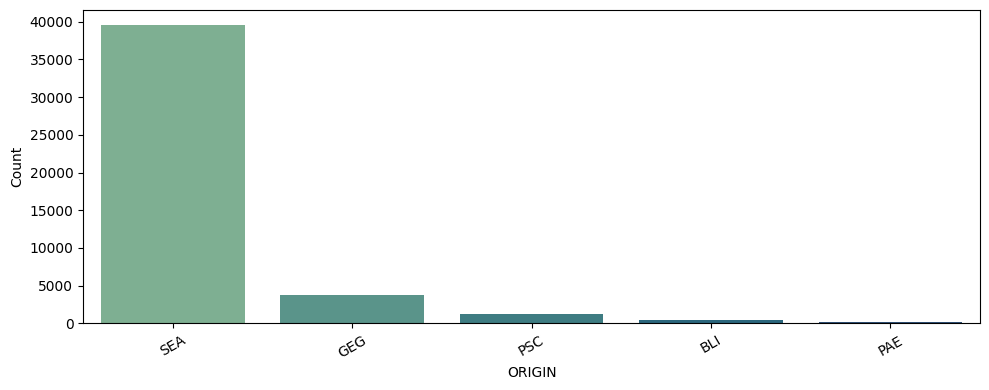

C:\Users\PC\AppData\Local\Temp\ipykernel_18268\254782690.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="viridis",


<Figure size 1000x400 with 0 Axes>

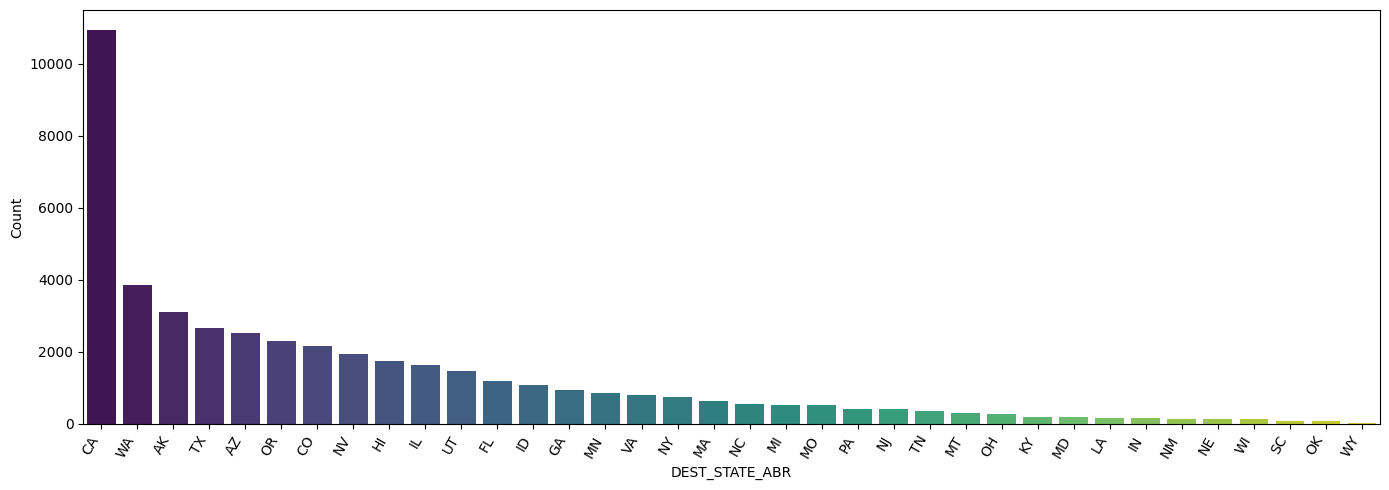

In [63]:
# Distribution of Categorical Features

selected_cat_cols = ["OP_UNIQUE_CARRIER", "ORIGIN", "DEST_STATE_ABR"]

for col in selected_cat_cols:
    plt.figure(figsize=(10, 4))
    if col == "DEST_STATE_ABR":
        plt.figure(figsize=(14, 5))
        sns.countplot(x=col, data=df, palette="viridis",
                      order=df[col].value_counts().index)
        # plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=60, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        sns.countplot(x=col, data=df, palette="crest",
                      order=df[col].value_counts().index)
        # plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()

## Bivariate Analysis with Target

### Flight Operation Factors

#### Delay Rate by Airline

C:\Users\PC\AppData\Local\Temp\ipykernel_18268\1866348372.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="OP_UNIQUE_CARRIER", y="DEP_DEL15", data=df, palette="crest",


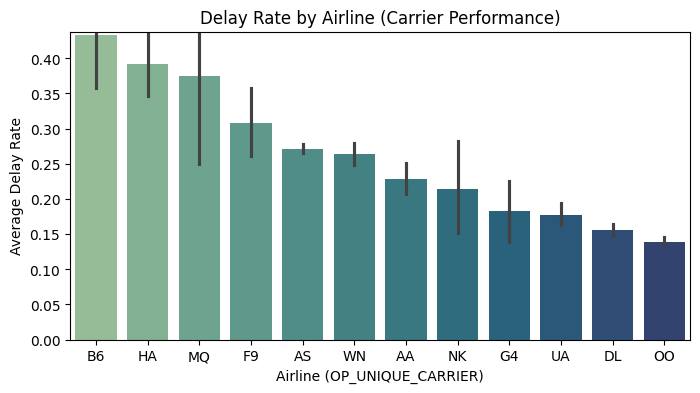

In [17]:
# ======================================================
# ✈️ 1. Delay Rate by Airline (Carrier Performance)
# ======================================================

plt.figure(figsize=(8,4))
sns.barplot(x="OP_UNIQUE_CARRIER", y="DEP_DEL15", data=df, palette="crest",
            order=df.groupby("OP_UNIQUE_CARRIER")["DEP_DEL15"].mean().sort_values(ascending=False).index)

plt.title("Delay Rate by Airline (Carrier Performance)")
plt.xlabel("Airline (OP_UNIQUE_CARRIER)")
plt.ylabel("Average Delay Rate")
plt.ylim(0, df["DEP_DEL15"].mean()*2)
plt.show()


The bar chart illustrates the average delay rate by airline. JetBlue (B6) and Hawaiian Airlines (HA) show the highest delay rates, whereas Delta (DL) and SkyWest (OO) have the lowest. This indicates that on-time performance varies significantly across carriers, suggesting airline-specific factors may strongly influence flight punctuality.

#### Delay Rate by Route (ORIGIN–DEST)

C:\Users\PC\AppData\Local\Temp\ipykernel_18268\1078567480.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="ROUTE", x="DEP_DEL15", data=top_routes, palette="rocket")


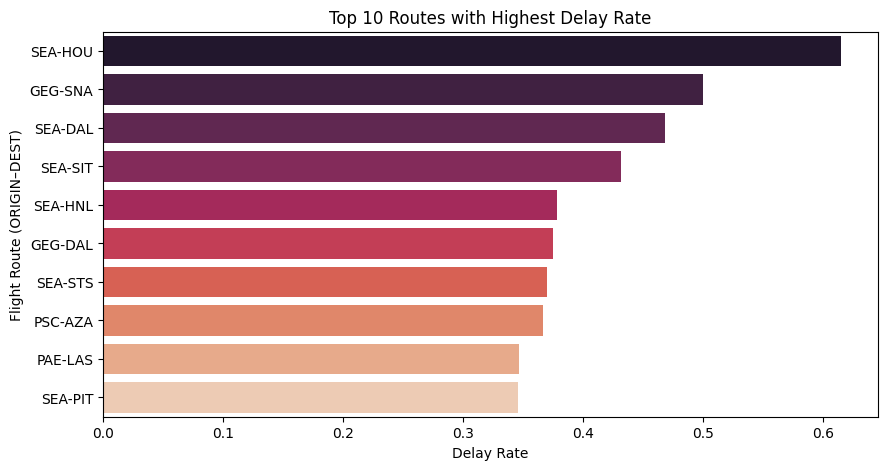

In [18]:
# ======================================================
# ✈️ 2. Delay Rate by Route (ORIGIN–DEST)
# ======================================================

# Create route column
df["ROUTE"] = df["ORIGIN"] + "-" + df["DEST"]

# Compute average delay rate by route
route_delay = (
    df.groupby("ROUTE")["DEP_DEL15"]
      .mean()
      .reset_index()
      .sort_values("DEP_DEL15", ascending=False)
)

# Select top 10 routes
top_routes = route_delay.head(10)

plt.figure(figsize=(10,5))
sns.barplot(y="ROUTE", x="DEP_DEL15", data=top_routes, palette="rocket")
plt.title("Top 10 Routes with Highest Delay Rate")
plt.xlabel("Delay Rate")
plt.ylabel("Flight Route (ORIGIN–DEST)")
plt.show()


#### Delay Rate by Airport (ORIGIN)

C:\Users\PC\AppData\Local\Temp\ipykernel_18268\2984606073.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="ORIGIN", y="DEP_DEL15", data=df, palette="coolwarm",


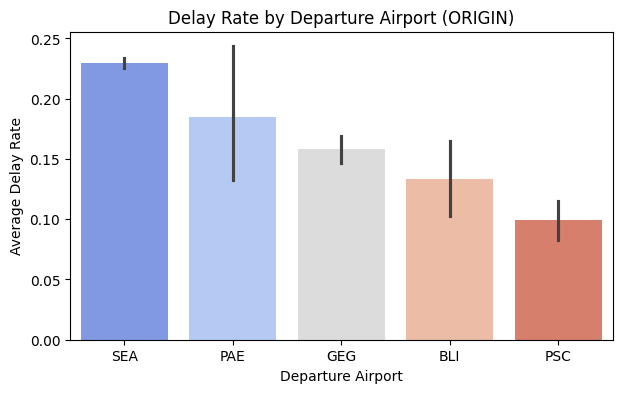

In [20]:
# ======================================================
# ✈️ 3. Delay Rate by Airport (ORIGIN)
# ======================================================

plt.figure(figsize=(7,4))
sns.barplot(x="ORIGIN", y="DEP_DEL15", data=df, palette="coolwarm",
            order=df.groupby("ORIGIN")["DEP_DEL15"].mean().sort_values(ascending=False).index)

plt.title("Delay Rate by Departure Airport (ORIGIN)")
plt.xlabel("Departure Airport")
plt.ylabel("Average Delay Rate")
plt.show()


#### Delay Rate by Distance Group

C:\Users\PC\AppData\Local\Temp\ipykernel_18268\1554291068.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="DISTANCE_GROUP", y="DEP_DEL15", data=df, palette="mako")


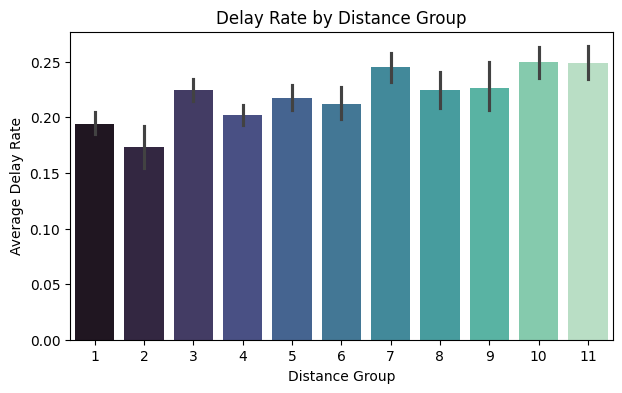

In [21]:
# ======================================================
# ✈️ 4. Delay Rate by Distance Group
# ======================================================

plt.figure(figsize=(7,4))
sns.barplot(x="DISTANCE_GROUP", y="DEP_DEL15", data=df, palette="mako")
plt.title("Delay Rate by Distance Group")
plt.xlabel("Distance Group")
plt.ylabel("Average Delay Rate")
plt.show()


### Time-Related Factors

#### Delay Rate by Time of Day

C:\Users\PC\AppData\Local\Temp\ipykernel_18268\2873956492.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="TIME_OF_DAY", y="DEP_DEL15", data=df,


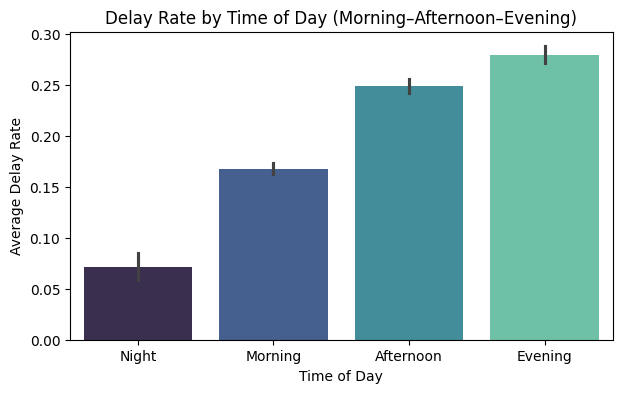

In [26]:
# ======================================================
# 🕒 5. Delay Rate by Time of Day (Morning / Afternoon / Evening)
# ======================================================

# Create a time-of-day category based on CRS_DEP_TIME (scheduled departure)
def classify_time(dep_time):
    hour = int(dep_time)
    if 0 <= hour < 6:
        return "Night"
    elif 6 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 18:
        return "Afternoon"
    else:
        return "Evening"

df["TIME_OF_DAY"] = df["CRS_DEP_TIME"].apply(classify_time)

plt.figure(figsize=(7,4))
sns.barplot(x="TIME_OF_DAY", y="DEP_DEL15", data=df,
            order=["Night","Morning","Afternoon","Evening"], palette="mako")
plt.title("Delay Rate by Time of Day (Morning–Afternoon–Evening)")
plt.xlabel("Time of Day")
plt.ylabel("Average Delay Rate")
plt.show()


#### Delay Rate by Scheduled Departure Hour

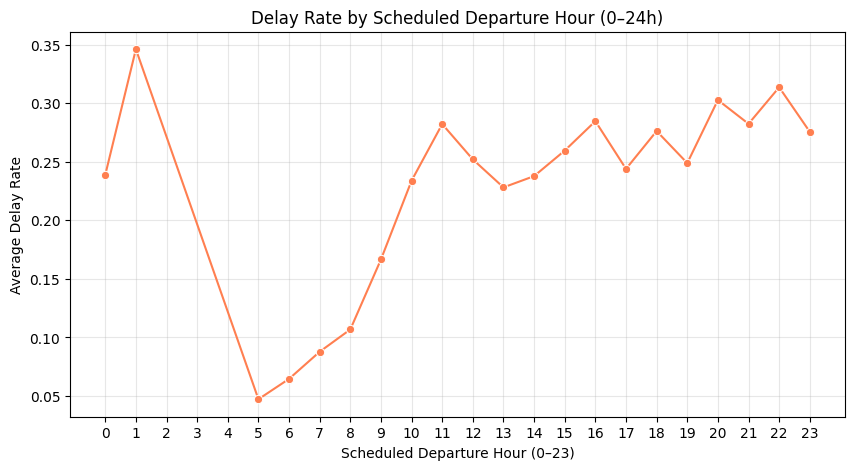

In [28]:
# ======================================================
# 🕒 6. Delay Rate by Scheduled Departure Hour (0–24h)
# ======================================================

# Extract hour component from CRS_DEP_TIME
df["DEP_HOUR"] = (df["CRS_DEP_TIME"]).astype(int)

hour_delay = df.groupby("DEP_HOUR")["DEP_DEL15"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(x="DEP_HOUR", y="DEP_DEL15", data=hour_delay,
             marker="o", color="coral")
plt.title("Delay Rate by Scheduled Departure Hour (0–24h)")
plt.xlabel("Scheduled Departure Hour (0–23)")
plt.ylabel("Average Delay Rate")
plt.xticks(range(0,24))
plt.grid(alpha=0.3)
plt.show()


#### Delay Rate by Day of Week

C:\Users\PC\AppData\Local\Temp\ipykernel_18268\513863547.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="DAY_NAME", y="DEP_DEL15", data=df,


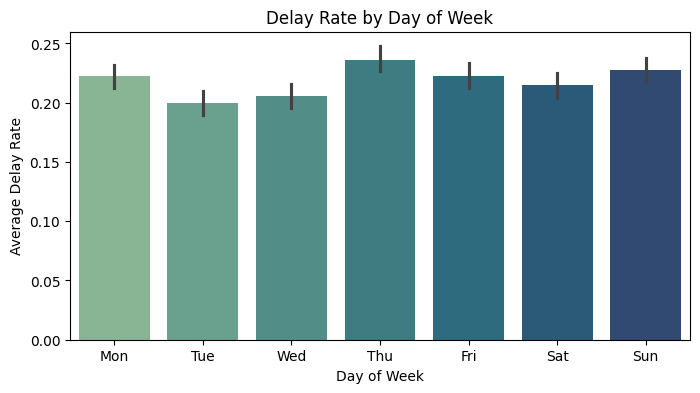

In [24]:
# ======================================================
# 🗓️ 7. Delay Rate by Day of Week
# ======================================================

# Map weekday numbers (1–7) to names (optional)
day_map = {1:"Mon", 2:"Tue", 3:"Wed", 4:"Thu", 5:"Fri", 6:"Sat", 7:"Sun"}
df["DAY_NAME"] = df["DAY_OF_WEEK"].map(day_map)

plt.figure(figsize=(8,4))
sns.barplot(x="DAY_NAME", y="DEP_DEL15", data=df,
            order=["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], palette="crest")
plt.title("Delay Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Delay Rate")
plt.show()


#### Delay Rate by Month

C:\Users\PC\AppData\Local\Temp\ipykernel_18268\864021261.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="MONTH", y="DEP_DEL15", data=df, palette="viridis")


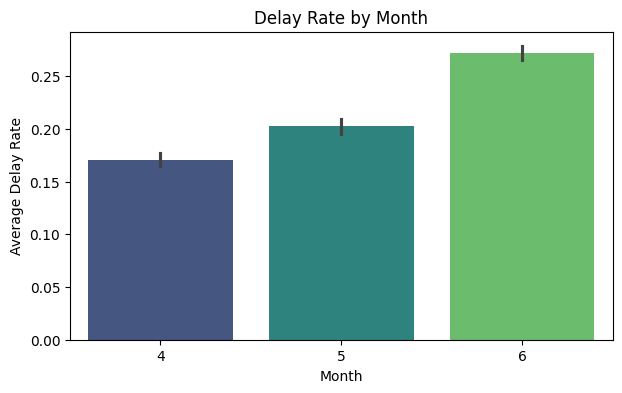

In [25]:
# ======================================================
# 📆 8. Delay Rate by Month
# ======================================================

plt.figure(figsize=(7,4))
sns.barplot(x="MONTH", y="DEP_DEL15", data=df, palette="viridis")
plt.title("Delay Rate by Month")
plt.xlabel("Month")
plt.ylabel("Average Delay Rate")
plt.show()


### Weather-Related Factors

#### Delay Rate by Visibility Level

C:\Users\PC\AppData\Local\Temp\ipykernel_18268\3682803232.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="VISIBILITY_GROUP", y="DEP_DEL15", data=df, palette="Blues")


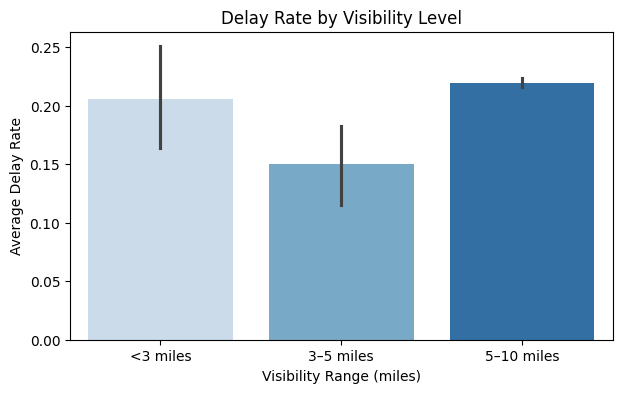

In [ ]:
bins = [0, 3, 5, 10] 
labels = ["<3 miles", "3–5 miles", "5–10 miles"]

df["VISIBILITY_GROUP"] = pd.cut(df["HourlyVisibility"], bins=bins, labels=labels, include_lowest=True)

plt.figure(figsize=(7,4))
sns.barplot(x="VISIBILITY_GROUP", y="DEP_DEL15", data=df, palette="Blues")
plt.title("Delay Rate by Visibility Level")
plt.xlabel("Visibility Range (miles)")
plt.ylabel("Average Delay Rate")
plt.show()

#### Delay Rate by Wind Speed Group

C:\Users\PC\AppData\Local\Temp\ipykernel_18268\1948763360.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="WIND_GROUP", y="DEP_DEL15", data=df, palette="coolwarm")


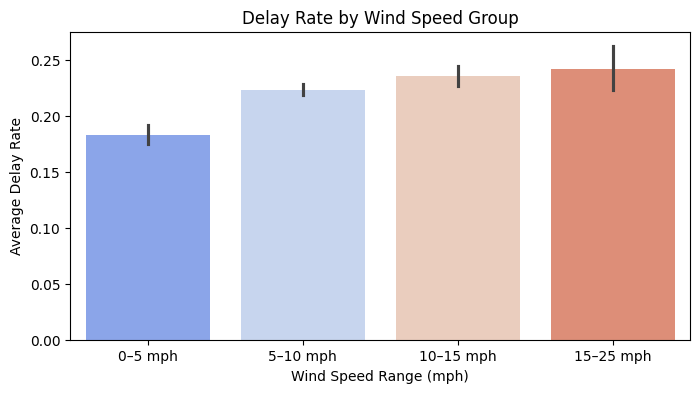

In [ ]:
bins = [0, 5, 10, 15, 25]
labels = ["0–5 mph", "5–10 mph", "10–15 mph", "15–25 mph"]

df["WIND_GROUP"] = pd.cut(df["HourlyWindSpeed"], bins=bins, labels=labels, include_lowest=True)

plt.figure(figsize=(8,4))
sns.barplot(x="WIND_GROUP", y="DEP_DEL15", data=df, palette="coolwarm")
plt.title("Delay Rate by Wind Speed Group")
plt.xlabel("Wind Speed Range (mph)")
plt.ylabel("Average Delay Rate")
plt.show()

#### Delay Rate by Temperature Bin (°C)

C:\Users\PC\AppData\Local\Temp\ipykernel_18268\3007096703.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="TEMP_GROUP", y="DEP_DEL15", data=df, palette="viridis")


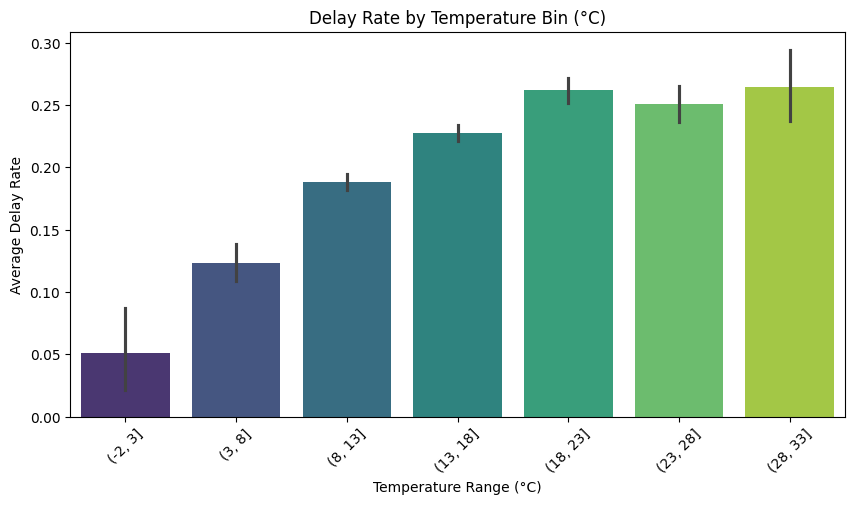

In [ ]:
df["HourlyDryBulbTemperature_C"] = (df["HourlyDryBulbTemperature"] - 32) * 5 / 9

bins = list(range(int(df["HourlyDryBulbTemperature_C"].min()) - 1,
                  int(df["HourlyDryBulbTemperature_C"].max()) + 5, 5))

df["TEMP_GROUP"] = pd.cut(df["HourlyDryBulbTemperature_C"], bins = bins[:-1])

plt.figure(figsize=(10,5))
sns.barplot(x="TEMP_GROUP", y="DEP_DEL15", data=df, palette="viridis")
plt.title("Delay Rate by Temperature Bin (°C)")
plt.xlabel("Temperature Range (°C)")
plt.ylabel("Average Delay Rate")
plt.xticks(rotation=45)
plt.show()

## Correlation and Statistical Tests

In [34]:
# ======================================================
# 📈 Correlation between Numeric Variables and Target (Point-Biserial)
# ======================================================

from scipy.stats import pointbiserialr

numeric_cols = [
    "DISTANCE", "CRS_ELAPSED_TIME", "CRS_DEP_TIME",
    "HourlyDryBulbTemperature", "HourlyWindSpeed", "HourlyVisibility",
    "HourlyRelativeHumidity"
]

correlations = []
for col in numeric_cols:
    r, p = pointbiserialr(df["DEP_DEL15"], df[col])
    correlations.append({"Feature": col, "Correlation (r)": round(r, 3), "p-value": round(p, 4)})

corr_df = pd.DataFrame(correlations).sort_values("Correlation (r)", ascending=False)
corr_df


,Feature,Correlation (r),p-value
2,CRS_DEP_TIME,0.146,0.0000
3,HourlyDryBulbTemperature,0.080,0.0000
4,HourlyWindSpeed,0.039,0.0000
0,DISTANCE,0.038,0.0000
1,CRS_ELAPSED_TIME,0.037,0.0000
5,HourlyVisibility,0.017,0.0003
6,HourlyRelativeHumidity,-0.037,0.0000


In [35]:
# ======================================================
# 🧮 Chi-Square Test for Categorical Variables
# ======================================================

from scipy.stats import chi2_contingency

cat_cols = ["OP_UNIQUE_CARRIER", "ORIGIN", "MONTH", "DAY_OF_WEEK", "TIME_OF_DAY"]

results = []
for col in cat_cols:
    ct = pd.crosstab(df[col], df["DEP_DEL15"])
    chi2, p, dof, exp = chi2_contingency(ct)
    results.append({"Feature": col, "Chi2": round(chi2, 2), "p-value": round(p, 6)})

chi_df = pd.DataFrame(results)
chi_df


,Feature,Chi2,p-value
0,OP_UNIQUE_CARRIER,1046.59,0.000000
1,ORIGIN,235.66,0.000000
2,MONTH,476.90,0.000000
3,DAY_OF_WEEK,36.45,0.000002
4,TIME_OF_DAY,774.44,0.000000


In [36]:
# ======================================================
# 🧪 T-test for Numeric Variables (Delayed vs On-time)
# ======================================================

from scipy.stats import ttest_ind

group_delayed = df[df["DEP_DEL15"] == 1]
group_ontime = df[df["DEP_DEL15"] == 0]

t_results = []
for col in numeric_cols:
    t_stat, p_val = ttest_ind(group_delayed[col], group_ontime[col], equal_var=False)
    t_results.append({"Feature": col, "t-statistic": round(t_stat, 2), "p-value": round(p_val, 6)})

t_df = pd.DataFrame(t_results)
t_df


,Feature,t-statistic,p-value
0,DISTANCE,8.10,0.000000
1,CRS_ELAPSED_TIME,7.81,0.000000
2,CRS_DEP_TIME,33.08,0.000000
3,HourlyDryBulbTemperature,17.28,0.000000
4,HourlyWindSpeed,8.45,0.000000
5,HourlyVisibility,3.84,0.000122
6,HourlyRelativeHumidity,-7.92,0.000000


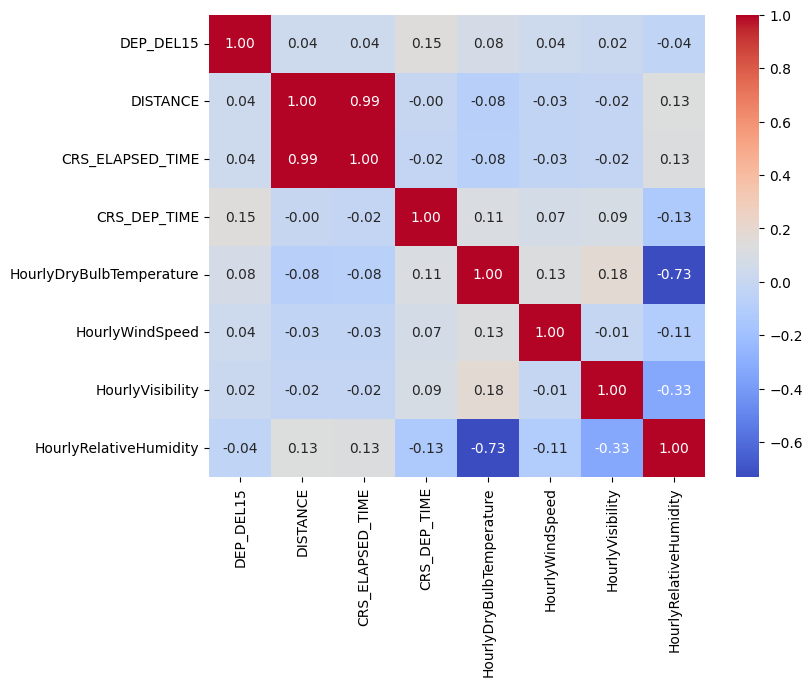

In [64]:
# 🔥 Correlation Heatmap for Numeric Features

plt.figure(figsize=(8,6))
corr_matrix = df[["DEP_DEL15"] + numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
# plt.title("Correlation Heatmap (Including DEP_DEL15)")
plt.show()

## Insights Summary

#### Thời gian xuất phát ảnh hưởng thế nào tới khả năng Delay

#### 

dest_state_percent = (
    df['DEST_STATE_ABR']
    .value_counts(normalize=True) * 100
).round(2)

print(dest_state_percent.head(10))  # chỉ xem top 10 bang


origin_percent = (
    df['ORIGIN']
    .value_counts(normalize=True) * 100
).round(2)

print(origin_percent)


In [60]:
dest_state_percent = (
    df['DEST_STATE_ABR']
    .value_counts(normalize=True) * 100
).round(2)

print(dest_state_percent.head(10))  # chỉ xem top 10 bang


DEST_STATE_ABR
CA    24.17
WA     8.53
AK     6.85
TX     5.88
AZ     5.60
OR     5.06
CO     4.75
NV     4.28
HI     3.87
IL     3.62
Name: proportion, dtype: float64


In [61]:
origin_percent = (
    df['ORIGIN']
    .value_counts(normalize=True) * 100
).round(2)

print(origin_percent)


ORIGIN
SEA    87.41
GEG     8.30
PSC     2.81
BLI     1.07
PAE     0.42
Name: proportion, dtype: float64
